# Experimento 10 (protocol analysis/Ga10)

Investigar a estrutura biomecânica da marcha em condição Ga10 utilizando K-Means sem redução dimensional.

A condição Ga10 representa caminhada realizada simultaneamente a uma tarefa aritmética de subtrações seriadas, caracterizando uma condição de alta carga cognitiva.

# 1. Importando as bibliotecas

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans

from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

from sklearn.decomposition import PCA

from google.colab import drive

# 2. Montando o Google Drive

In [2]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# 3. Carregando o Dataset Baseline

In [3]:
BASE_PATH = Path('/content/drive/MyDrive/results')

ga_file = BASE_PATH / 'ga_baseline_features.csv'

ga_df = pd.read_csv(ga_file)

ga_df.head()

,dataset,patient_id,mean_total_L,mean_total_R,std_total_L,std_total_R,cv_total_L,cv_total_R,assimetria_mean,assimetria_abs,peak_force_L,peak_force_R
0,Ga,GaPt24_10,473.238435,502.094442,411.342104,422.206326,0.869207,0.840890,-28.856007,28.856007,1188.55,1210.77
1,Ga,GaCo09_02,470.210635,423.825689,409.763042,374.653720,0.871446,0.883981,46.384946,46.384946,1151.26,983.62
2,Ga,GaPt14_10,540.243175,425.180815,461.761851,389.215544,0.854730,0.915412,115.062360,115.062360,1276.00,1092.96
3,Ga,GaPt08_02,391.887131,419.585864,340.767717,370.100560,0.869556,0.882062,-27.698733,27.698733,904.86,927.74
4,Ga,GaPt28_10,591.748944,593.337949,488.596962,482.026601,0.825683,0.812398,-1.589005,1.589005,1324.84,1342.77


In [4]:
ga_df.shape

(113, 12)

In [5]:
ga_df.info()
ga_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113 entries, 0 to 112
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   dataset          113 non-null    object 
 1   patient_id       113 non-null    object 
 2   mean_total_L     113 non-null    float64
 3   mean_total_R     113 non-null    float64
 4   std_total_L      113 non-null    float64
 5   std_total_R      113 non-null    float64
 6   cv_total_L       113 non-null    float64
 7   cv_total_R       113 non-null    float64
 8   assimetria_mean  113 non-null    float64
 9   assimetria_abs   113 non-null    float64
 10  peak_force_L     113 non-null    float64
 11  peak_force_R     113 non-null    float64
dtypes: float64(10), object(2)
memory usage: 10.7+ KB


,mean_total_L,mean_total_R,std_total_L,std_total_R,cv_total_L,cv_total_R,assimetria_mean,assimetria_abs,peak_force_L,peak_force_R
count,113.000000,113.000000,113.000000,113.000000,113.000000,113.000000,113.000000,113.000000,113.000000,113.000000
mean,456.106407,453.179806,390.404618,390.801528,0.858148,0.864323,2.926601,29.814904,1067.167434,1067.701858
std,83.577924,74.299393,69.877364,61.712805,0.051668,0.044486,40.217414,27.004009,190.617166,177.123386
min,257.118875,251.897876,226.298854,224.369987,0.638924,0.733060,-88.564178,0.159885,709.720000,678.150000
25%,398.778065,410.042114,345.657151,353.674325,0.840844,0.838905,-23.040766,9.624151,927.080000,933.130000
50%,453.086596,450.764434,382.636669,390.274977,0.861489,0.862900,1.974890,22.384324,1042.580000,1059.960000
75%,500.367435,497.457205,436.683412,424.511506,0.877496,0.883867,19.906996,41.885811,1198.890000,1175.130000
max,665.698361,634.581404,535.475736,539.934434,1.178253,1.163285,122.906652,122.906652,1507.880000,1504.580000


### Filtrando somente a condição Ga10

In [6]:
ga10_df = ga_df[
    ga_df['patient_id'].str.endswith('_10')
]

ga10_df.head()

,dataset,patient_id,mean_total_L,mean_total_R,std_total_L,std_total_R,cv_total_L,cv_total_R,assimetria_mean,assimetria_abs,peak_force_L,peak_force_R
0,Ga,GaPt24_10,473.238435,502.094442,411.342104,422.206326,0.869207,0.840890,-28.856007,28.856007,1188.55,1210.77
2,Ga,GaPt14_10,540.243175,425.180815,461.761851,389.215544,0.854730,0.915412,115.062360,115.062360,1276.00,1092.96
4,Ga,GaPt28_10,591.748944,593.337949,488.596962,482.026601,0.825683,0.812398,-1.589005,1.589005,1324.84,1342.77
7,Ga,GaPt15_10,382.553705,463.702899,322.817946,412.162583,0.843850,0.888851,-81.149194,81.149194,924.44,1073.27
16,Ga,GaPt20_10,394.247525,450.764434,335.287634,381.189312,0.850450,0.845651,-56.516909,56.516909,886.05,968.44


Verificando o subconjunto

In [7]:
ga10_df.shape

(27, 12)

In [8]:
ga10_df['patient_id'].head(5)

,patient_id
0,GaPt24_10
2,GaPt14_10
4,GaPt28_10
7,GaPt15_10
16,GaPt20_10


### Estatísticas descritivas sobre o subconjunto

In [9]:
ga10_df.describe()

,mean_total_L,mean_total_R,std_total_L,std_total_R,cv_total_L,cv_total_R,assimetria_mean,assimetria_abs,peak_force_L,peak_force_R
count,27.000000,27.000000,27.000000,27.000000,27.000000,27.000000,27.000000,27.000000,27.000000,27.000000
mean,449.375304,442.676226,380.984129,377.311806,0.854783,0.857572,6.699078,30.959596,1044.458148,1037.018889
std,93.754983,82.744003,72.941403,64.995202,0.084266,0.074206,43.861222,31.225769,188.253920,178.960293
min,257.118875,251.897876,226.298854,224.369987,0.638924,0.733060,-81.149194,1.589005,709.720000,678.150000
25%,393.746008,401.743940,340.063054,345.197930,0.829417,0.818403,-23.605139,7.495812,895.895000,911.570000
50%,453.705270,441.512961,362.766541,381.189312,0.846010,0.845640,2.384383,23.043053,1025.090000,1016.840000
75%,487.112735,480.198115,423.778393,413.864829,0.880855,0.882753,20.130613,37.578710,1187.945000,1158.080000
max,665.698361,631.153151,531.809759,533.728594,1.178253,1.163285,115.062360,115.062360,1501.940000,1448.040000


# 4. Defininção das features

Removendo colunas não utilizadas no clustering

In [11]:
feature_cols = [
    'mean_total_L',
    'mean_total_R',

    'std_total_L',
    'std_total_R',

    'cv_total_L',
    'cv_total_R',

    'assimetria_mean',
    'assimetria_abs',

    'peak_force_L',
    'peak_force_R'
]

X = ga10_df[feature_cols]

# 5. Normalização dos dados

In [12]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# 6. Escolha do número de clusters

## Elbow Method

In [13]:
inertia = []

k_values = range(2, 7)

for k in k_values:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    inertia.append(kmeans.inertia_)

Visualizando o Elbow Method

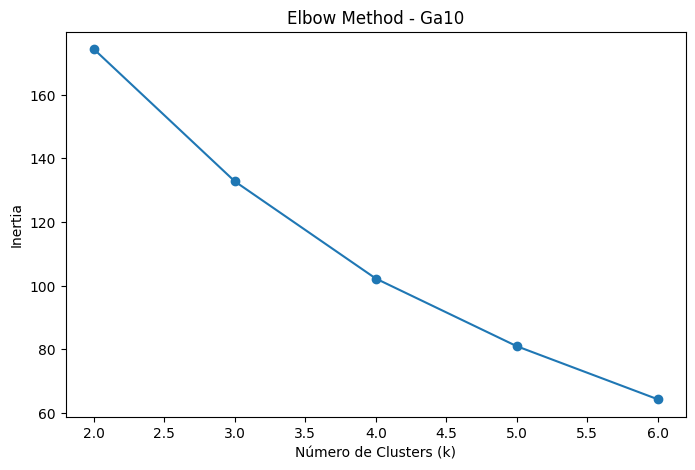

In [32]:
plt.figure(figsize=(8,5))

plt.plot(k_values, inertia, marker='o')

plt.title('Elbow Method - Ga10')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inertia')

plt.show()

# 7. Avaliação com Silhouette Score

In [15]:
silhouette_scores = []

for k in k_values:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels
    )

    silhouette_scores.append(score)

    print(f'k={k} | Silhouette Score: {score:.4f}')

k=2 | Silhouette Score: 0.3141
k=3 | Silhouette Score: 0.3007
k=4 | Silhouette Score: 0.2175
k=5 | Silhouette Score: 0.2261
k=6 | Silhouette Score: 0.2806


Vizualização com o Silhouette Score

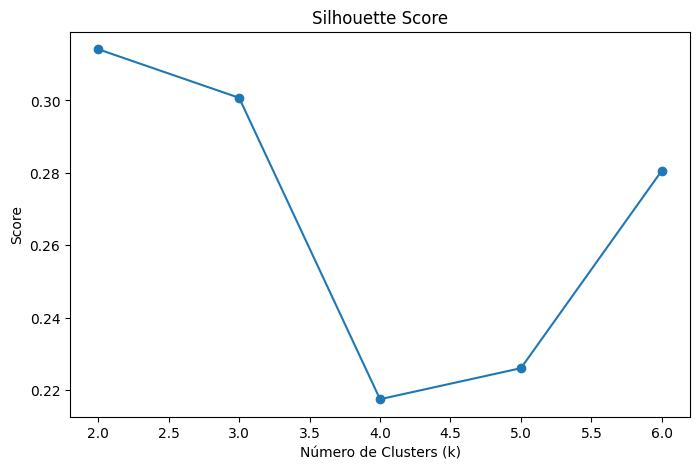

In [16]:
plt.figure(figsize=(8,5))

plt.plot(
    k_values,
    silhouette_scores,
    marker='o'
)

plt.title('Silhouette Score')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Score')

plt.show()

# 8. Treinamento final com o K-Means

In [17]:
kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

Adicionando clusters ao dataframe

In [19]:
ga10_df['cluster'] = clusters

ga10_df.head()

/tmp/ipykernel_28916/2670973436.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ga10_df['cluster'] = clusters


,dataset,patient_id,mean_total_L,mean_total_R,std_total_L,std_total_R,cv_total_L,cv_total_R,assimetria_mean,assimetria_abs,peak_force_L,peak_force_R,cluster
0,Ga,GaPt24_10,473.238435,502.094442,411.342104,422.206326,0.869207,0.840890,-28.856007,28.856007,1188.55,1210.77,0
2,Ga,GaPt14_10,540.243175,425.180815,461.761851,389.215544,0.854730,0.915412,115.062360,115.062360,1276.00,1092.96,0
4,Ga,GaPt28_10,591.748944,593.337949,488.596962,482.026601,0.825683,0.812398,-1.589005,1.589005,1324.84,1342.77,0
7,Ga,GaPt15_10,382.553705,463.702899,322.817946,412.162583,0.843850,0.888851,-81.149194,81.149194,924.44,1073.27,1
16,Ga,GaPt20_10,394.247525,450.764434,335.287634,381.189312,0.850450,0.845651,-56.516909,56.516909,886.05,968.44,1


# 9. Métricas Internas

In [20]:
silhouette = silhouette_score(
    X_scaled,
    clusters
)

davies = davies_bouldin_score(
    X_scaled,
    clusters
)

calinski = calinski_harabasz_score(
    X_scaled,
    clusters
)

print(f'Silhouette Score: {silhouette:.4f}')
print(f'Davies-Bouldin Index: {davies:.4f}')
print(f'Calinski-Harabasz Score: {calinski:.4f}')

Silhouette Score: 0.3141
Davies-Bouldin Index: 1.0803
Calinski-Harabasz Score: 13.7440


# 10. Visualização dos Clusters

PCA somente usado para visualização

In [21]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

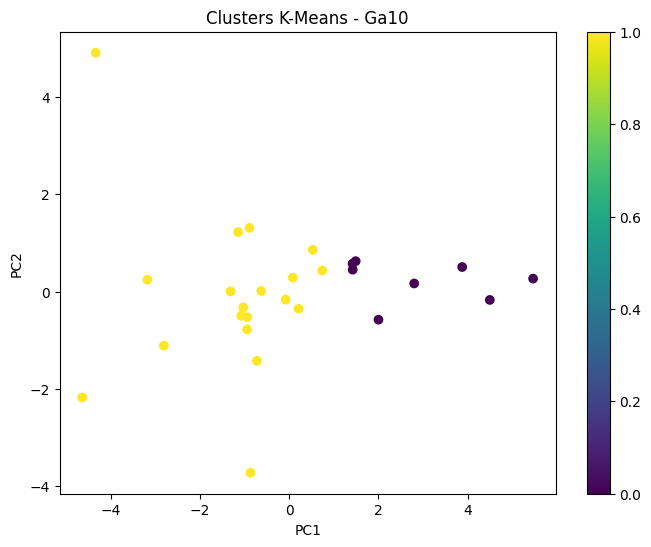

In [23]:
plt.figure(figsize=(8,6))

scatter = plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=clusters
)

plt.title('Clusters K-Means - Ga10')
plt.xlabel('PC1')
plt.ylabel('PC2')

plt.colorbar(scatter)

plt.show()

# 11. HeatMap dos centroídes

In [24]:
centroids = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=feature_cols
)

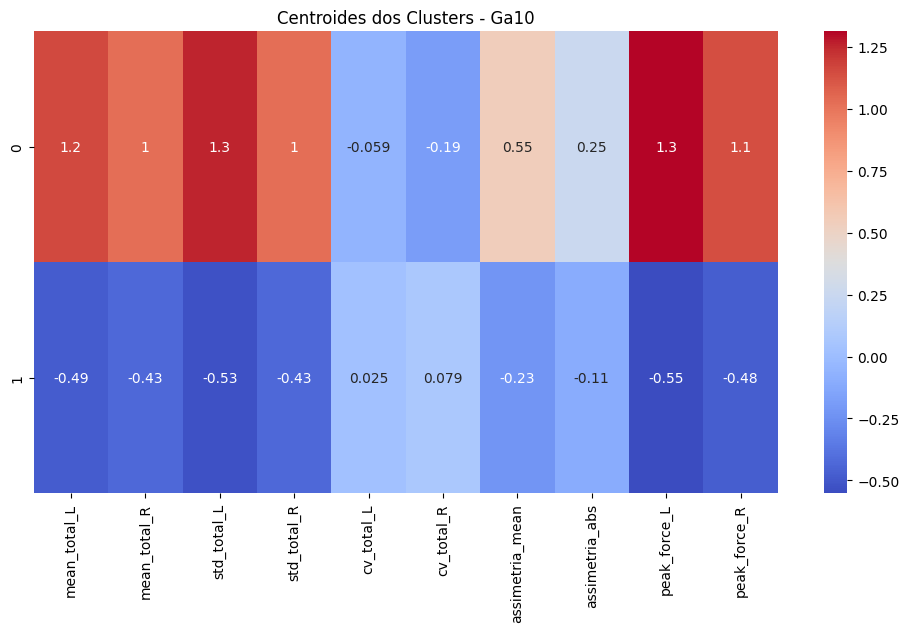

In [26]:
plt.figure(figsize=(12,6))

sns.heatmap(
    centroids,
    annot=True,
    cmap='coolwarm'
)

plt.title('Centroides dos Clusters - Ga10')

plt.show()

# 12. Distribuição dos Clusters

In [27]:
ga10_df['cluster'].value_counts()

,count
cluster,
1,19
0,8


# 13. Composição por Grupo Clínico

Parkinson vs Controle

In [28]:
ga10_df['grupo'] = np.where(
    ga10_df['patient_id'].str.contains('Pt'),
    'Parkinson',
    'Controle'
)

/tmp/ipykernel_28916/3844689002.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ga10_df['grupo'] = np.where(


In [30]:
pd.crosstab(
    ga10_df['cluster'],
    ga10_df['grupo']
)

grupo,Controle,Parkinson
cluster,,
0,0,8
1,6,13


# 14. Média das features por cluster

In [31]:
ga10_df.groupby(
    'cluster'
)[feature_cols].mean()

,mean_total_L,mean_total_R,std_total_L,std_total_R,cv_total_L,cv_total_R,assimetria_mean,assimetria_abs,peak_force_L,peak_force_R
cluster,,,,,,,,,,
0,555.782294,525.609419,470.868221,442.529064,0.849941,0.843992,30.172876,38.750747,1286.945000,1237.128750
1,404.572360,407.756987,343.138196,349.851907,0.856822,0.863290,-3.184626,27.679112,942.358421,952.762105
